# Shark Tank India Dataset Analysis

### Objective:
Analyze the Shark Tank India dataset to understand:
- How many pitches were made and how many got funded.
- The total and average investment amounts.
- Insights by sharks (investors) — who invested the most and in which sectors.
- Startup trends — by sector, location, gender, and valuation.

### Tools:
- Python
- Pandas, NumPy (for data manipulation)
- Matplotlib, Seaborn (for visualization)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/ashutoshmishra/Downloads/Shark Tank India.csv")

In [3]:
# View first 5 rows
df.head()

# Check shape (rows, columns)
df.shape

# Column names
df.columns

# Info about data types and null values
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              634 non-null    int64  
 1   Startup Name               634 non-null    object 
 2   Episode Number             634 non-null    int64  
 3   Pitch Number               634 non-null    int64  
 4   Season Start               634 non-null    object 
 5   Season End                 634 non-null    object 
 6   Original Air Date          603 non-null    object 
 7   Episode Title              634 non-null    object 
 8   Anchor                     634 non-null    object 
 9   Industry                   634 non-null    object 
 10  Business Description       634 non-null    object 
 11  Company Website            625 non-null    object 
 12  Started in                 577 non-null    float64
 13  Number of Presenters       634 non-null    int64  

Season Number       0
Startup Name        0
Episode Number      0
Pitch Number        0
Season Start        0
                 ... 
Aman Present       78
Peyush Present    246
Ritesh Present    496
Amit Present      497
Guest Present     323
Length: 80, dtype: int64

In [4]:
df.describe(include='all')

,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Invested Guest Name,All Guest Names,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
count,634.000000,634,634.000000,634.000000,634,634,603,634,634,634,...,63,311,495.0,428.0,548.0,556.0,388.0,138.0,137.0,311.000000
unique,NaN,634,NaN,NaN,4,4,189,190,6,18,...,15,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,BluePineFoods,NaN,NaN,02-Jan-23,10-Mar-23,04-Feb-22,Unseen,Rahul Dua,Food and Beverage,...,Ashneer Grover,Ashneer Grover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,169,169,7,31,319,142,...,20,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.500000,NaN,24.055205,317.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.131833
std,1.106137,NaN,15.102549,183.164316,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.338854
min,1.000000,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
25%,2.000000,NaN,11.000000,159.250000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
50%,2.000000,NaN,24.000000,317.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
75%,3.000000,NaN,36.000000,475.750000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000


In [5]:
df.isnull().sum()

Season Number       0
Startup Name        0
Episode Number      0
Pitch Number        0
Season Start        0
                 ... 
Aman Present       78
Peyush Present    246
Ritesh Present    496
Amit Present      497
Guest Present     323
Length: 80, dtype: int64

In [6]:
# Fill investment-related Nas with 0
investment_cols = ['Amount Invested', 'Equity Taken', 'Deal Amount'] 
for col in investment_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [7]:
# Fill Deal column
if 'Deal' in df.columns:
    df['Deal'] = df['Deal'].fillna('No')

In [8]:
# Fill text columns (like sector, location)
for col in ['Sector', 'Industry', 'City']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [9]:
# Fill presence columns with 0
presence_cols = [col for col in df.columns if 'Present' in col]
for col in presence_cols:
    df[col] = df[col].fillna(0)

In [10]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
#Check for datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              634 non-null    int64  
 1   Startup Name               634 non-null    object 
 2   Episode Number             634 non-null    int64  
 3   Pitch Number               634 non-null    int64  
 4   Season Start               634 non-null    object 
 5   Season End                 634 non-null    object 
 6   Original Air Date          603 non-null    object 
 7   Episode Title              634 non-null    object 
 8   Anchor                     634 non-null    object 
 9   Industry                   634 non-null    object 
 10  Business Description       634 non-null    object 
 11  Company Website            625 non-null    object 
 12  Started in                 577 non-null    float64
 13  Number of Presenters       634 non-null    int64  

In [12]:
df['Season Start'] = pd.to_datetime(df['Season Start'], errors='coerce')
df['Season End'] = pd.to_datetime(df['Season End'], errors='coerce')
df['Original Air Date'] = pd.to_datetime(df['Original Air Date'], errors='coerce')

/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/379537403.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Season Start'] = pd.to_datetime(df['Season Start'], errors='coerce')
/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/379537403.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Season End'] = pd.to_datetime(df['Season End'], errors='coerce')
/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/379537403.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Original Air Date'] = pd.to_datetime(df['Original Air Da

In [13]:
df[['Season Start', 'Season End', 'Original Air Date']].head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Season Number              634 non-null    int64         
 1   Startup Name               634 non-null    object        
 2   Episode Number             634 non-null    int64         
 3   Pitch Number               634 non-null    int64         
 4   Season Start               634 non-null    datetime64[ns]
 5   Season End                 634 non-null    datetime64[ns]
 6   Original Air Date          603 non-null    datetime64[ns]
 7   Episode Title              634 non-null    object        
 8   Anchor                     634 non-null    object        
 9   Industry                   634 non-null    object        
 10  Business Description       634 non-null    object        
 11  Company Website            625 non-null    object        
 12  Started 

In [14]:
df['Pitchers City'] = df['Pitchers City'].apply(lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else x)
df['Pitchers State'] = df['Pitchers State'].apply(lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else x)


In [15]:
#checking
df.isnull().sum().sort_values(ascending=False)

Part of Match off          628
Guest Debt Amount          628
Amit Debt Amount           627
Anupam Debt Amount         625
Advisory Shares Equity     623
                          ... 
Pitchers Average Age         0
Original Ask Amount          0
Original Offered Equity      0
Valuation Requested          0
Guest Present                0
Length: 80, dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Season Number              634 non-null    int64         
 1   Startup Name               634 non-null    object        
 2   Episode Number             634 non-null    int64         
 3   Pitch Number               634 non-null    int64         
 4   Season Start               634 non-null    datetime64[ns]
 5   Season End                 634 non-null    datetime64[ns]
 6   Original Air Date          603 non-null    datetime64[ns]
 7   Episode Title              634 non-null    object        
 8   Anchor                     634 non-null    object        
 9   Industry                   634 non-null    object        
 10  Business Description       634 non-null    object        
 11  Company Website            625 non-null    object        
 12  Started 

Exploratory Data Analysis (EDA)

In [18]:
df.describe(include='all')


,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Invested Guest Name,All Guest Names,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
count,634.000000,634,634.000000,634.000000,634,634,603,634,634,634,...,63,311,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
unique,NaN,634,NaN,NaN,NaN,NaN,NaN,190,6,18,...,15,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,BluePineFoods,NaN,NaN,NaN,NaN,NaN,Unseen,Rahul Dua,Food and Beverage,...,Ashneer Grover,Ashneer Grover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,31,319,142,...,20,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.500000,NaN,24.055205,317.500000,2023-07-06 13:35:23.659305984,2023-09-08 00:15:53.943217664,2023-09-06 02:08:57.313432832,NaN,NaN,NaN,...,NaN,NaN,0.780757,0.675079,0.864353,0.876972,0.611987,0.217666,0.216088,0.555205
min,1.000000,NaN,0.000000,1.000000,2021-12-20 00:00:00,2022-02-04 00:00:00,2021-12-20 00:00:00,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,NaN,11.000000,159.250000,2023-01-02 00:00:00,2023-03-10 00:00:00,2023-01-14 12:00:00,NaN,NaN,NaN,...,NaN,NaN,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,NaN,24.000000,317.500000,2023-01-02 00:00:00,2023-03-10 00:00:00,2024-01-25 00:00:00,NaN,NaN,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,3.000000,NaN,36.000000,475.750000,2024-01-22 00:00:00,2024-03-31 00:00:00,2025-01-07 00:00:00,NaN,NaN,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,4.000000,NaN,52.000000,634.000000,2025-01-06 00:00:00,2025-03-18 00:00:00,2025-03-18 00:00:00,NaN,NaN,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [19]:
total_pitches = df.shape[0]
offers_received = df['Received Offer'].sum()
deals_accepted = df['Accepted Offer'].sum()

print(f"Total pitches: {total_pitches}")
print(f"Offers received: {offers_received} ({offers_received / total_pitches:.2%})")
print(f"Deals accepted: {deals_accepted} ({deals_accepted / total_pitches:.2%})")


Total pitches: 634
Offers received: 423 (66.72%)
Deals accepted: 360.0 (56.78%)


In [20]:
#Percentage of deal per person
df.groupby('Season Number')['Accepted Offer'].mean() * 100


Season Number
1    72.916667
2    87.603306
3    88.461538
4    90.196078
Name: Accepted Offer, dtype: float64

In [21]:
#Highest total investment
df.groupby('Season Number')['Total Deal Amount'].sum().sort_values(ascending=False)


Season Number
4    8549.30000
2    6981.00000
3    6730.01250
1    4024.60106
Name: Total Deal Amount, dtype: float64

In [22]:
#Total investment by each shark
shark_cols = ['Aman Investment Amount', 'Namita Investment Amount', 'Peyush Investment Amount', 'Anupam Investment Amount', 'Vineeta Investment Amount']
df[shark_cols].sum().sort_values(ascending=False)

Aman Investment Amount       5453.717516
Peyush Investment Amount     4072.914753
Namita Investment Amount     4061.839268
Anupam Investment Amount     3397.330768
Vineeta Investment Amount    2987.294500
dtype: float64

In [23]:
#Top 10 most common startup industries
df['Industry'].value_counts().head(10)


Industry
Food and Beverage               142
Beauty/Fashion                  127
Technology/Software              58
Medical/Health                   56
Manufacturing                    52
Lifestyle/Home                   43
Business Services                42
Children/Education               25
Vehicles/Electrical Vehicles     20
Fitness/Sports/Outdoors          19
Name: count, dtype: int64

In [24]:
#which sectors get the most deals
df.groupby('Industry')['Accepted Offer'].mean().sort_values(ascending=False).head(10)

Industry
Electronics                     1.000000
Entertainment                   1.000000
Animal/Pets                     1.000000
Hardware                        1.000000
Fitness/Sports/Outdoors         0.937500
Medical/Health                  0.931818
Vehicles/Electrical Vehicles    0.909091
Children/Education              0.888889
Technology/Software             0.878049
Beauty/Fashion                  0.850575
Name: Accepted Offer, dtype: float64

In [25]:
#Insights by Location
df['Pitchers State'].value_counts().head(10)
df.groupby('Pitchers State')['Accepted Offer'].mean().sort_values(ascending=False).head(10)



Pitchers State
Arunachal Pradesh    1.0
Jammu & Kashmir      1.0
Uttarakhand          1.0
Tamil Nadu           1.0
Odisha               1.0
Meghalaya            1.0
Assam                1.0
Jharkhand            1.0
Kerala               1.0
Himachal Pradesh     1.0
Name: Accepted Offer, dtype: float64

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/3842126878.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='cool')


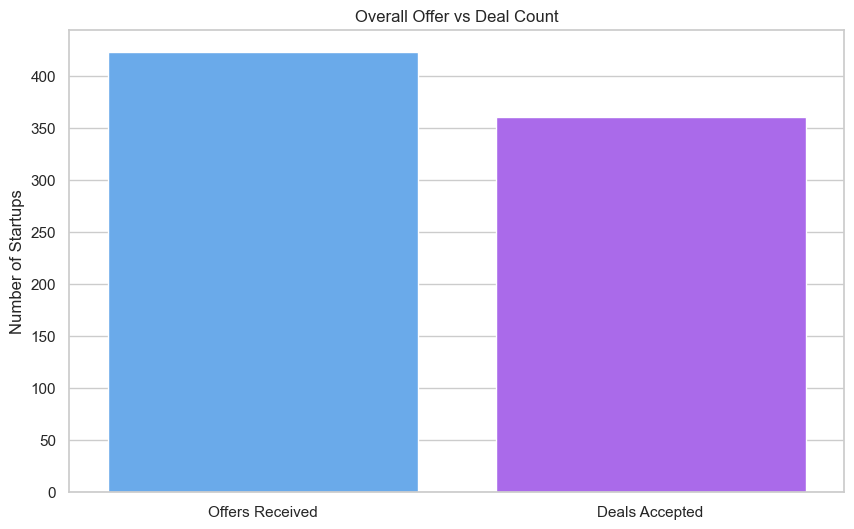

In [27]:
#how many startups got offers and how many closed deals.
offers_received = df['Received Offer'].sum()
deals_accepted  = df['Accepted Offer'].sum()

labels = ['Offers Received', 'Deals Accepted']
values = [offers_received, deals_accepted]

sns.barplot(x=labels, y=values, palette='cool')
plt.title("Overall Offer vs Deal Count")
plt.ylabel("Number of Startups")
plt.show()


/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/4210879140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')


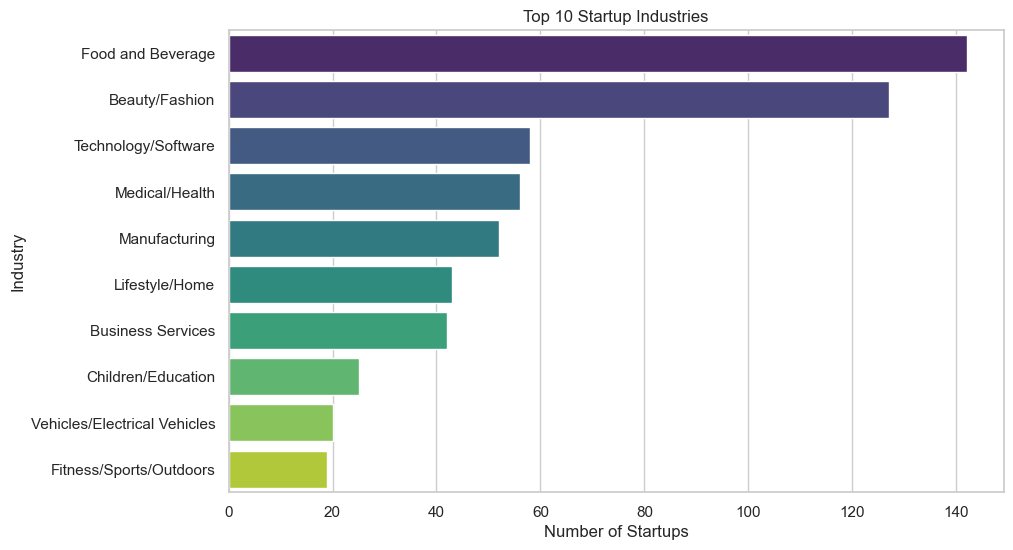

In [28]:
#Top Industries on Shark Tank India
top_industries = df['Industry'].value_counts().head(10)

sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.title("Top 10 Startup Industries")
plt.xlabel("Number of Startups")
plt.ylabel("Industry")
plt.show()


/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/3276972635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_investment_by_shark.values,


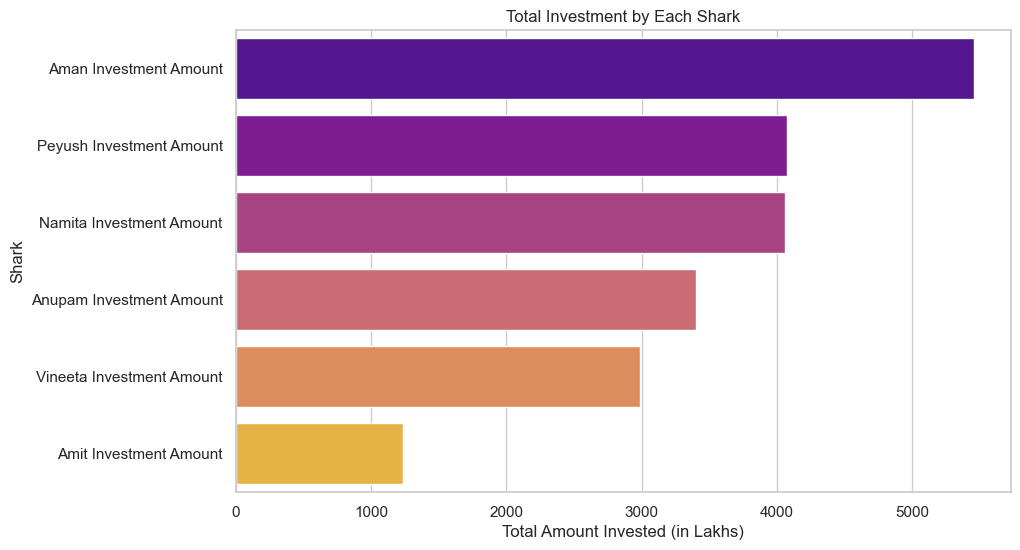

In [29]:
#Total Investment by Shark:
shark_cols = ['Aman Investment Amount', 'Namita Investment Amount', 'Peyush Investment Amount',
              'Anupam Investment Amount', 'Vineeta Investment Amount', 'Amit Investment Amount']

total_investment_by_shark = df[shark_cols].sum().sort_values(ascending=False)

sns.barplot(x=total_investment_by_shark.values, 
            y=total_investment_by_shark.index, palette='plasma')
plt.title("Total Investment by Each Shark")
plt.xlabel("Total Amount Invested (in Lakhs)")
plt.ylabel("Shark")
plt.show()



/var/folders/yl/wy9_2fp936q6x5q3yvk_zcrh0000gn/T/ipykernel_2393/984023425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deals_by_season.index, y=deals_by_season.values, palette='mako')


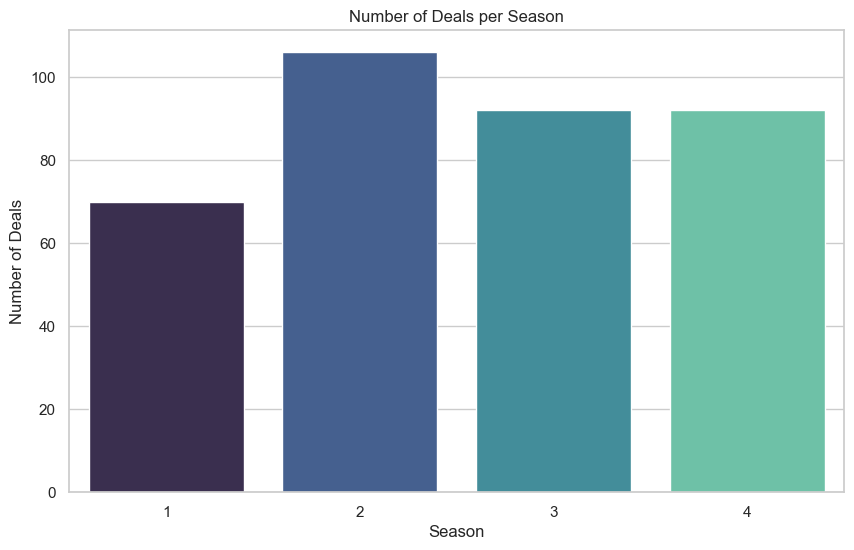

In [30]:
#Deals per Season
deals_by_season = df.groupby('Season Number')['Accepted Offer'].sum()

sns.barplot(x=deals_by_season.index, y=deals_by_season.values, palette='mako')
plt.title("Number of Deals per Season")
plt.xlabel("Season")
plt.ylabel("Number of Deals")
plt.show()


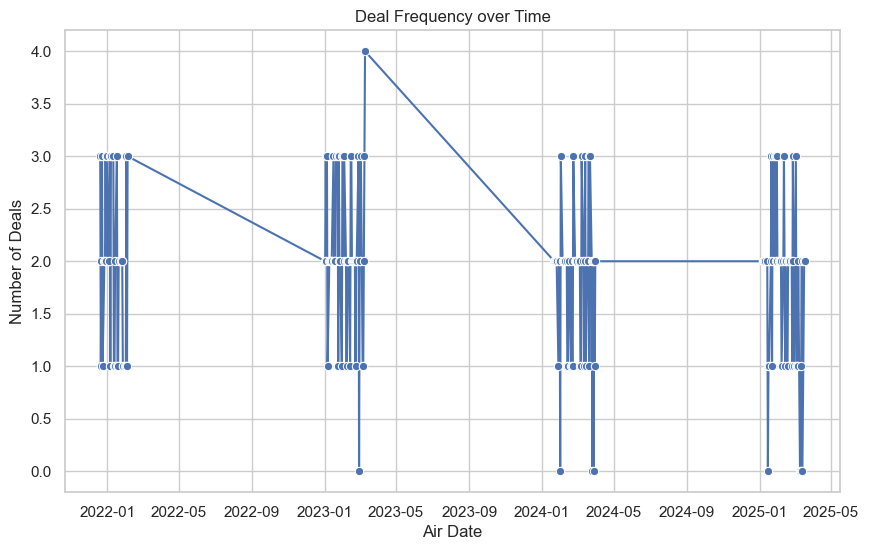

In [31]:
#Investment Trend over Time
investment_trend = df.groupby('Original Air Date')['Accepted Offer'].sum().reset_index()

sns.lineplot(data=investment_trend, x='Original Air Date', y='Accepted Offer', marker='o')
plt.title("Deal Frequency over Time")
plt.xlabel("Air Date")
plt.ylabel("Number of Deals")
plt.show()


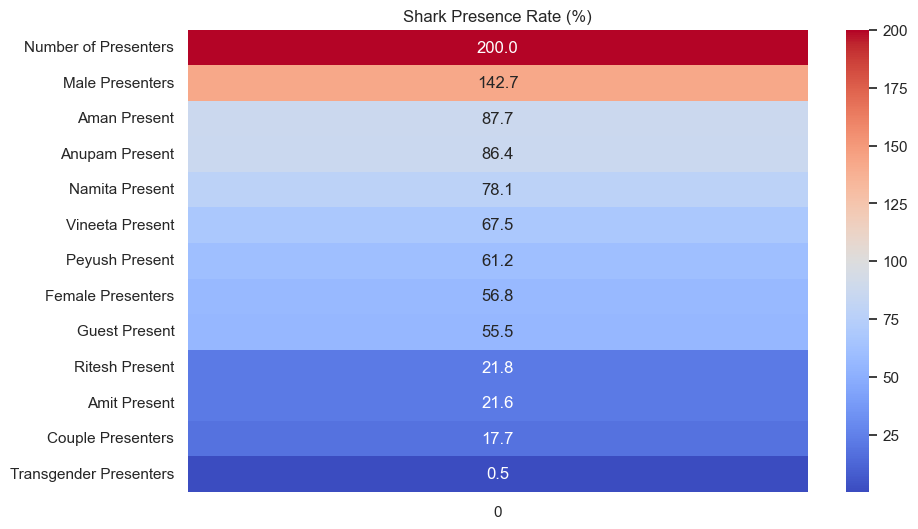

In [32]:
#Heatmap of Shark Presence
present_cols = [col for col in df.columns if 'Present' in col]
shark_presence = df[present_cols].mean().sort_values(ascending=False) * 100

sns.heatmap(shark_presence.to_frame(), annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Shark Presence Rate (%)")
plt.show()


In [33]:
#Deal Conversion Rates by Industry
industry_conversion = (
    df.groupby('Industry')[['Received Offer', 'Accepted Offer']]
    .sum()
)
industry_conversion['Conversion Rate'] = (
    industry_conversion['Accepted Offer'] / industry_conversion['Received Offer']
) * 100

industry_conversion = industry_conversion.sort_values(by='Conversion Rate', ascending=False)
industry_conversion.head(10)

,Received Offer,Accepted Offer,Conversion Rate
Industry,,,
Electronics,3,3.0,100.000000
Entertainment,1,1.0,100.000000
Animal/Pets,2,2.0,100.000000
Hardware,1,1.0,100.000000
Fitness/Sports/Outdoors,16,15.0,93.750000
Medical/Health,44,41.0,93.181818
Vehicles/Electrical Vehicles,11,10.0,90.909091
Children/Education,18,16.0,88.888889
Technology/Software,41,36.0,87.804878


In [34]:
#Average Investment per Deal by Industry:
avg_investment_by_industry = (
    df.groupby('Industry')['Total Deal Amount'].mean()
    .sort_values(ascending=False)
)
avg_investment_by_industry.head(10)


Industry
Entertainment              150.000000
Electronics                133.333333
Liquor/Alcohol              90.000000
Green/CleanTech             85.626563
Medical/Health              82.512220
Beauty/Fashion              80.243243
Technology/Software         80.194444
Business Services           75.833333
Fitness/Sports/Outdoors     73.666667
Children/Education          67.875000
Name: Total Deal Amount, dtype: float64

In [35]:
#Shark Behavior Analysis:
shark_cols = ['Aman Investment Amount', 'Namita Investment Amount', 'Peyush Investment Amount',
              'Anupam Investment Amount', 'Vineeta Investment Amount', 'Amit Investment Amount']

# How often each shark invested
shark_participation = (df[shark_cols] > 0).sum().sort_values(ascending=False)

# How much each shark invested
shark_investments = df[shark_cols].sum().sort_values(ascending=False)

shark_stats = pd.DataFrame({
    'Deals Participated': shark_participation,
    'Total Invested (Lakhs)': shark_investments,
    'Avg Investment per Deal': shark_investments / shark_participation
})

shark_stats


,Deals Participated,Total Invested (Lakhs),Avg Investment per Deal
Aman Investment Amount,140,5453.717516,38.955125
Amit Investment Amount,35,1234.400000,35.268571
Anupam Investment Amount,101,3397.330768,33.636938
Namita Investment Amount,114,4061.839268,35.630169
Peyush Investment Amount,103,4072.914753,39.542862
Vineeta Investment Amount,89,2987.294500,33.565107


In [36]:
import itertools

In [37]:
#Shark Collaboration Network
import itertools

# Create all pairs of sharks
pairs = list(itertools.combinations(shark_cols, 2))

pair_data = []
for s1, s2 in pairs:
    both_invested = ((df[s1] > 0) & (df[s2] > 0)).sum()
    pair_data.append((s1, s2, both_invested))

pair_df = pd.DataFrame(pair_data, columns=['Shark 1', 'Shark 2', 'Deals Together'])
pair_df.sort_values(by='Deals Together', ascending=False).head(10)


,Shark 1,Shark 2,Deals Together
0,Aman Investment Amount,Namita Investment Amount,44
1,Aman Investment Amount,Peyush Investment Amount,44
2,Aman Investment Amount,Anupam Investment Amount,43
9,Peyush Investment Amount,Anupam Investment Amount,36
12,Anupam Investment Amount,Vineeta Investment Amount,36
3,Aman Investment Amount,Vineeta Investment Amount,32
5,Namita Investment Amount,Peyush Investment Amount,27
6,Namita Investment Amount,Anupam Investment Amount,27
7,Namita Investment Amount,Vineeta Investment Amount,27
10,Peyush Investment Amount,Vineeta Investment Amount,26


In [38]:
#Where do successful startups come from?
state_success = df.groupby('Pitchers State')['Accepted Offer'].mean().sort_values(ascending=False) * 100
state_success.head(10)


Pitchers State
Arunachal Pradesh    100.0
Jammu & Kashmir      100.0
Uttarakhand          100.0
Tamil Nadu           100.0
Odisha               100.0
Meghalaya            100.0
Assam                100.0
Jharkhand            100.0
Kerala               100.0
Himachal Pradesh     100.0
Name: Accepted Offer, dtype: float64

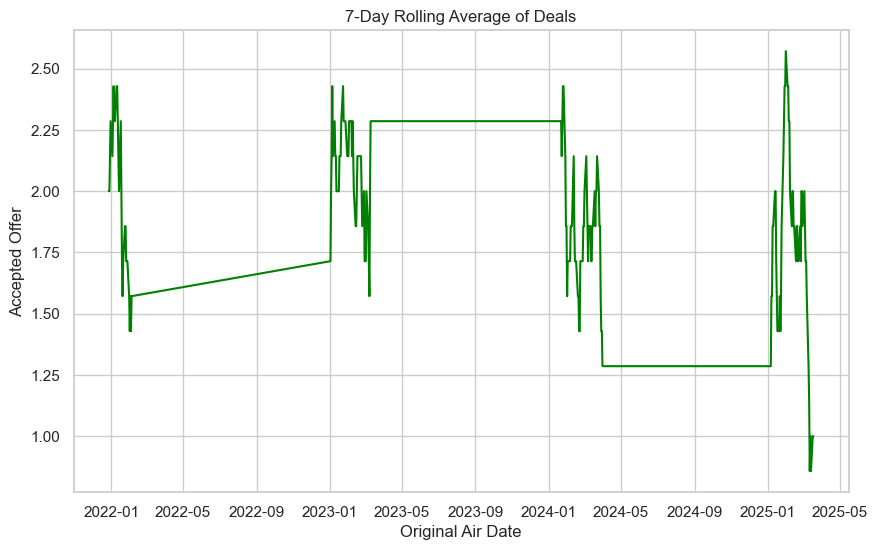

In [39]:
#Deals Over Time
deals_over_time = (
    df.groupby('Original Air Date')['Accepted Offer']
    .sum()
    .rolling(window=7).mean()
    .reset_index()
)
sns.lineplot(data=deals_over_time, x='Original Air Date', y='Accepted Offer', color='green')
plt.title("7-Day Rolling Average of Deals")
plt.show()


In [40]:
#Ask vs. Received Analysis
df['Negotiation Ratio'] = df['Total Deal Amount'] / df['Original Ask Amount']
df['Negotiation Ratio'].describe()


count       359.000000
mean        279.633651
std        5277.740932
min           0.010000
25%           1.000000
50%           1.000000
75%           1.000000
max      100000.000000
Name: Negotiation Ratio, dtype: float64